# 5th : KNN

2026.04.29

In [1]:
import pickle
import numpy as np
import tarfile
import os

In [6]:
data_tar_path = 'cifar-10-batches-py.tar'

with tarfile.open(data_tar_path, 'r') as tar:
    tar.extractall('.')

/tmp/ipykernel_2971/3084300182.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


In [7]:
def load_cifar10_data(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    images = batch[b'data']
    labels = batch[b'labels']
    return images, np.array(labels)

data_dir = 'cifar-10-batches-py'

all_train_images = []
all_train_labels = []

for i in range(1, 6):  # data_batch_1 ~ data_batch_5
    batch_path = os.path.join(data_dir, f'data_batch_{i}')
    images, labels = load_cifar10_data(batch_path)
    all_train_images.append(images)
    all_train_labels.append(labels)

# load whole train dataset
all_train_images = np.concatenate(all_train_images, axis=0)
all_train_labels = np.concatenate(all_train_labels, axis=0)

# load whole test dataset
test_path = os.path.join(data_dir, 'test_batch')
all_test_images, all_test_labels = load_cifar10_data(test_path)

print(f"Train dataset: {all_train_images.shape}")
print(f"Test dataset: {all_test_images.shape}")

Train dataset: (50000, 3072)
Test dataset: (10000, 3072)


In [8]:
# Each label should have an equal number of samples for balanced training
# make subset (train : 500/class, test : 100/class)
TRAIN_PER_CLASS = 500
TEST_PER_CLASS  = 100

rng = np.random.default_rng(seed=42)

def stratified_sample(images, labels, n_per_class):
    selected_idx = []
    for class_id in range(10):  # 10 classes
        class_idx = np.where(labels == class_id)[0]
        chosen = rng.choice(class_idx, size=n_per_class, replace=False)
        selected_idx.append(chosen) # mixup

    selected_idx = np.concatenate(selected_idx)
    rng.shuffle(selected_idx)

    return images[selected_idx], labels[selected_idx]

train_images, train_labels = stratified_sample(all_train_images, all_train_labels, TRAIN_PER_CLASS)
test_images,  test_labels  = stratified_sample(all_test_images,  all_test_labels,  TEST_PER_CLASS)

print(f"train image shape: {train_images.shape}, train label: {train_labels.shape}")
print(f"test image shape:  {test_images.shape}, test label: {test_labels.shape}")

print("\n[Train] number of samples per class:")
for c in range(10):
    print(f"class {c}: {(train_labels == c).sum()}")

print("\n[Test] number of samples per class:")
for c in range(10):
    print(f"class {c}: {(test_labels == c).sum()}")

train image shape: (5000, 3072), train label: (5000,)
test image shape:  (1000, 3072), test label: (1000,)

[Train] number of samples per class:
class 0: 500
class 1: 500
class 2: 500
class 3: 500
class 4: 500
class 5: 500
class 6: 500
class 7: 500
class 8: 500
class 9: 500

[Test] number of samples per class:
class 0: 100
class 1: 100
class 2: 100
class 3: 100
class 4: 100
class 5: 100
class 6: 100
class 7: 100
class 8: 100
class 9: 100


output <br>
train image shape: (5000, 3072), train label: (5000,)  
test image shape:  (1000, 3072), test label: (1000,)  
already flatten

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

class KNNClassifier:
    def __init__(self, k=3, metric='l2'):
        self.k = k
        self.metric = metric  # 'l1' or 'l2'

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def distance(self, a):
        if self.metric == 'l1':
            return np.sum(np.abs(self.X_train - a), axis=1)
        else:  # l2
            return np.sqrt(np.sum((self.X_train - a) ** 2, axis=1))

    def predict(self, X):
        X = np.array(X)
        preds = []
        for x in X:
            dists = self.distance(x, self.X_train)
            k_idx = np.argsort(dists)[:self.k]
            k_labels = self.y_train[k_idx]
            most_common = Counter(k_labels).most_common(1)[0][0]
            preds.append(most_common)
        return np.array(preds)

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))

In [ ]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

K_VALUES  = [1, 3, 5, 7, 9]
METRICS   = ['l1', 'l2']
N_FOLDS   = 5
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

train_images_np = np.array(train_images)
train_labels_np = np.array(train_labels)
test_images_np  = np.array(test_images)
test_labels_np  = np.array(test_labels)

mean_cv = {metric: {} for metric in METRICS}

for metric in METRICS:
    print(f"\nMetric: {metric}")
    for k in K_VALUES:
        fold_scores = []
        for train_idx, val_idx in kf.split(train_images_np):
            X_tr, X_val = train_images_np[train_idx], train_images_np[val_idx]
            y_tr, y_val = train_labels_np[train_idx], train_labels_np[val_idx]

            knn = KNNClassifier(k=k, metric=metric)
            knn.fit(X_tr, y_tr)
            fold_scores.append(knn.score(X_val, y_val))

        fold_scores = np.array(fold_scores)
        mean_cv[metric][k] = fold_scores.mean()
        print(f"  K={k} | folds={np.round(fold_scores, 4)} | mean={fold_scores.mean():.4f}")

best_k = {metric: max(mean_cv[metric], key=mean_cv[metric].get) for metric in METRICS}
print(f"\nBest K → L1: {best_k['l1']}, L2: {best_k['l2']}")


# ── TP / FP / FN / TN ──
for metric in METRICS:
    k = best_k[metric]

    knn = KNNClassifier(k=k, metric=metric)
    knn.fit(train_images_np, train_labels_np)
    pred_labels = knn.predict(test_images_np)

    print(f"\n[{metric.upper()} | K={k}]")
    rows = []
    for i, cls in enumerate(CLASS_NAMES):
        tp = ((test_labels_np == i) & (pred_labels == i)).sum()
        fp = ((test_labels_np != i) & (pred_labels == i)).sum()
        fn = ((test_labels_np == i) & (pred_labels != i)).sum()
        tn = ((test_labels_np != i) & (pred_labels != i)).sum()
        rows.append({'Class': cls, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})

    display(pd.DataFrame(rows).set_index('Class'))


Metric: l1
  K=1 | folds=[0.196 0.195 0.195 0.185 0.192] | mean=0.1926
  K=3 | folds=[0.214 0.195 0.203 0.195 0.184] | mean=0.1982
  K=5 | folds=[0.208 0.209 0.205 0.208 0.186] | mean=0.2032
  K=7 | folds=[0.212 0.23  0.203 0.223 0.191] | mean=0.2118
  K=9 | folds=[0.205 0.221 0.214 0.214 0.195] | mean=0.2098

Metric: l2
  K=1 | folds=[0.186 0.198 0.193 0.182 0.2  ] | mean=0.1918
  K=3 | folds=[0.197 0.209 0.192 0.185 0.215] | mean=0.1996
  K=5 | folds=[0.203 0.215 0.187 0.2   0.203] | mean=0.2016
  K=7 | folds=[0.203 0.217 0.179 0.205 0.231] | mean=0.2070
  K=9 | folds=[0.194 0.207 0.175 0.201 0.212] | mean=0.1978

Best K → L1: 7, L2: 7

[L1 | K=7]


,TP,FP,FN,TN
Class,,,,
airplane,73,244,27,656
automobile,7,16,93,884
bird,24,124,76,776
cat,8,36,92,864
deer,27,121,73,779
dog,18,60,82,840
frog,6,36,94,864
horse,6,23,94,877
ship,44,113,56,787



[L2 | K=7]


,TP,FP,FN,TN
Class,,,,
airplane,60,308,40,592
automobile,17,38,83,862
bird,23,124,77,776
cat,5,47,95,853
deer,17,71,83,829
dog,8,36,92,864
frog,13,21,87,879
horse,8,26,92,874
ship,35,106,65,794


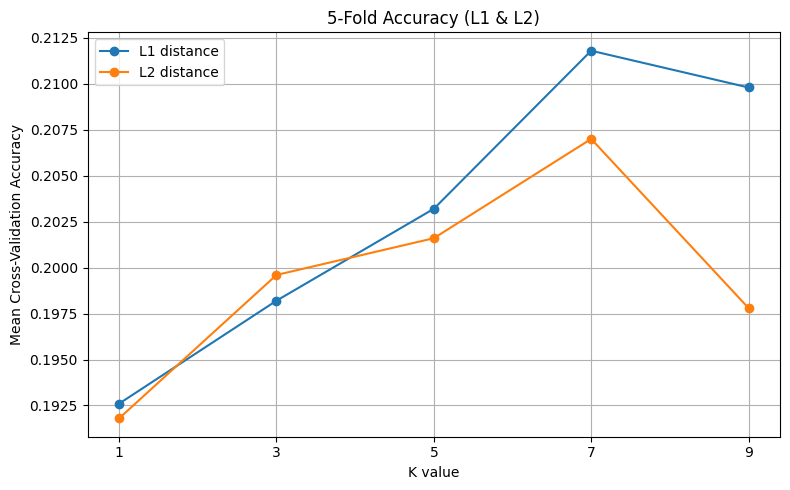

In [15]:
plt.figure(figsize=(8, 5))
for metric in METRICS:
    accs = [mean_cv[metric][k] for k in K_VALUES]
    plt.plot(K_VALUES, accs, marker='o', label=f'{metric.upper()} distance')

plt.xlabel('K value')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('5-Fold Accuracy (L1 & L2)')
plt.xticks(K_VALUES)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()